# Imports & Data Filtering

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
from scipy.stats import rankdata, norm
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

from IPython.display import Image, display

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # to minimise output verbosity later

In [6]:
# file paths
DB_PATH = 'human_genome_old.db' 
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'

In [7]:
SAMPLE_ID = 'random_id' 

In [8]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet(GERMLINE_DATA_PATH)
somatic_raw = pd.read_parquet(SOMATIC_DATA_PATH)
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

In [9]:
splicing = pd.read_parquet(SPLICING_DATA_PATH)
outrider = pd.read_parquet(EXPRESSION_DATA_PATH)
protein = pd.read_parquet(PROTEIN_DATA_PATH)

In [10]:
# format ensembl gene ID column to match database
res['geneID_filtered'] = res['Gene'].str.split('.').str[0].str.strip()
outrider['geneID_filtered'] = outrider['geneID_short'].str.split('.').str[0].str.strip()
protein['geneID_filtered'] = protein['geneID_short'].str.split('.').str[0].str.strip()
splicing['geneID_filtered'] = splicing['geneID_short'].str.split('.').str[0].str.strip()

In [11]:
# get generic gene names instead of symbols
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

In [12]:
def map_and_clean_ids(df, id_column):
    df['geneID_filtered'] = df[id_column].astype(str).str.split('.').str[0].str.strip() # just for double security
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    return df

res = map_and_clean_ids(res, 'Gene')
outrider = map_and_clean_ids(outrider, 'geneID_short')
protein = map_and_clean_ids(protein, 'geneID_short')
splicing = map_and_clean_ids(splicing, 'geneID_short')

In [13]:
# map chromosome number to each gene
res['chrom'] = res['seqnames'] # if a column already has the corresponding chromosomes

conn = sqlite3.connect(DB_PATH)
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

# for the dataframes that do not have the chromosomes already mapped
outrider['chrom'] = outrider['geneID_filtered'].map(gene_chrom_map)
protein['chrom'] = protein['geneID_filtered'].map(gene_chrom_map)
splicing['chrom'] = splicing['geneID_filtered'].map(gene_chrom_map)

In [14]:
# matrix of counts per sample per chromosome => needed for chromosome-aware stats test
def get_chrom_counts(outlier_df, sample_id=SAMPLE_ID):
    return outlier_df.groupby([sample_id, 'chrom']).size().unstack(fill_value=0)

all_ids = res[SAMPLE_ID].unique()

chrom_counts_gene = get_chrom_counts(outrider).reindex(all_ids, fill_value=0)
chrom_counts_prot = get_chrom_counts(protein).reindex(all_ids, fill_value=0)
chrom_counts_spl = get_chrom_counts(splicing).reindex(all_ids, fill_value=0)

# for gene + protein overlap
gene_prot_overlap = pd.merge(
    outrider,
    protein,
    on=[SAMPLE_ID, 'geneID_filtered', 'chrom']
).drop_duplicates(subset=[SAMPLE_ID, 'geneID_filtered'])

chrom_counts_gene_prot_overlap = get_chrom_counts(gene_prot_overlap).reindex(all_ids, fill_value=0)

In [15]:
# calculate sample-gene burdens
def calculate_burdens(outrider_df, protein_df, splicing_df, res_df, sample_id=SAMPLE_ID):
    burdens = {}

    burdens['gene'] = outrider_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['protein'] = protein_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['splicing'] = splicing_df.groupby(sample_id)['geneID_filtered'].nunique()

    all_samples = res_df[sample_id].unique()
    return {k: v.reindex(all_samples, fill_value=0).reset_index(name='burden') for k, v in burdens.items()}

In [16]:
# get the testable genes by checking if they have minimum n carriers
def get_testable_genes(outlier_df, res_df, min_carriers=5):
    outlier_genes = set(outlier_df['geneID_filtered'].unique())
    res_filtered = res_df[res_df['geneID_filtered'].isin(outlier_genes)]

    carrier_counts = (
        res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
        ['geneID_filtered']
        .value_counts()
    )

    valid_genes = carrier_counts[carrier_counts >= min_carriers].index.tolist()

    print(f"Total testable genes (conventional names): {len(valid_genes)}")
    return valid_genes

# Zero-inflated models

Zero-inflated Poisson test

In [17]:
# gene exp + protein overlap
strict_overlap = pd.merge(
    outrider[[SAMPLE_ID, 'geneID_filtered']].drop_duplicates(),
    protein[[SAMPLE_ID, 'geneID_filtered']].drop_duplicates(),
    on=[SAMPLE_ID, 'geneID_filtered']
)

overlap_counts = strict_overlap.groupby(SAMPLE_ID)['geneID_filtered'].nunique()
all_samples = res[SAMPLE_ID].unique()
burden_df = overlap_counts.reindex(all_samples, fill_value=0).reset_index(name='burden')

In [ ]:
# zero inflated poisson statistical test
def run_zip_tests(genes_to_test, res_df, burden_df):
    results = []
    failed_counts = {'non_convergence': 0, 'exceptions': 0}

    res_copy = res_df.copy()
    def summarize_variant(group):
        origins = set(group['origin'])
        types = set(group['Type'])
        if 'somatic' in origins and 'germline' in origins:
            origin_label = "Both"
        else:
            origin_label = list(origins)[0].capitalize()
        type_label = "/".join(sorted(types))
        return f"{origin_label}_{type_label}"

    for gene in tqdm(genes_to_test, desc="Running zero-inflated Poisson test"):
            gene_data = res_copy[res_copy['geneID_filtered'] == gene]

            if not gene_data.empty:
                variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
            else:
                variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

            model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')

            model_data['has_cnv'] = np.where(model_data['CNV_Type'].isna(), 0, 1)

            Y = model_data['burden']
            X = sm.add_constant(model_data['has_cnv'])

            n_carriers = model_data['has_cnv'].sum()

            if n_carriers < 3:
                continue

            try:
                zip_model = ZeroInflatedPoisson(endog=Y, exog=X, exog_infl=X, inflation='logit')
                zip_results = zip_model.fit(disp=False)

                if not zip_results.converged:
                    failed_counts["non_convergence"] += 1

                p_val = zip_results.pvalues['has_cnv']
                coef = zip_results.params['has_cnv']

                results.append({
                    'Gene': gene,
                    'n_carriers': n_carriers,
                    'coef': coef,
                    'p_val': p_val,
                    'converged': zip_results.converged
                })

            except Exception as e:
                failed_counts['exceptions'] += 1
                pass

    print(f"Done. Failed to converge: {failed_counts['non_convergence']}, Errors: {failed_counts['exceptions']}")

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['p_val'])
        _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
        results_df = results_df.sort_values('p_val')

    return results_df

In [21]:
# run the zip test
carrier_counts = (
    res[res['geneID_filtered'].isin(strict_overlap['geneID_filtered'])]
    .drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
    ['geneID_filtered']
    .value_counts()
)

genes_strict_overlap = carrier_counts[carrier_counts >= 5].index.tolist()

zip_stats = run_zip_tests(genes_strict_overlap, res, burden_df)

Running zero-inflated Poisson test:   0%|          | 0/623 [00:00<?, ?it/s]

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

Done. Failed to converge: 234, Errors: 0


/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
zip_stats['converged'].value_counts() # => about 1/3 of genes fail to converge with the Poisson test, despite promising p values

converged
True     389
False    234
Name: count, dtype: int64

In [22]:
# plot the zip results
def plot_zip_results(top_genes_list, res_df, burden_df, stats_df):
    for gene in top_genes_list:
        gene_stats = stats_df[stats_df['Gene'] == gene].iloc[0]
        p_val = gene_stats['p_val']
        p_adj = gene_stats['padj']
        coef = gene_stats['coef']
        fold_change = np.exp(coef) # e^coef gives the fold change in burden

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        plot_df = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))

        sns.boxplot(data=plot_df, x='Group', y='burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8)

        plt.title(f"{gene}\n"
                  f"(ZIP padj = {p_adj:.2e} | Exp. Increase: {fold_change:.1f}x)",
                  fontsize=15, pad=15)

        plt.ylabel("# of gene expression + protein overlap outliers", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            plt.legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        #plt.savefig(f'ZIP_Result_{gene}.png', dpi=300, bbox_inches='tight')
        plt.show()

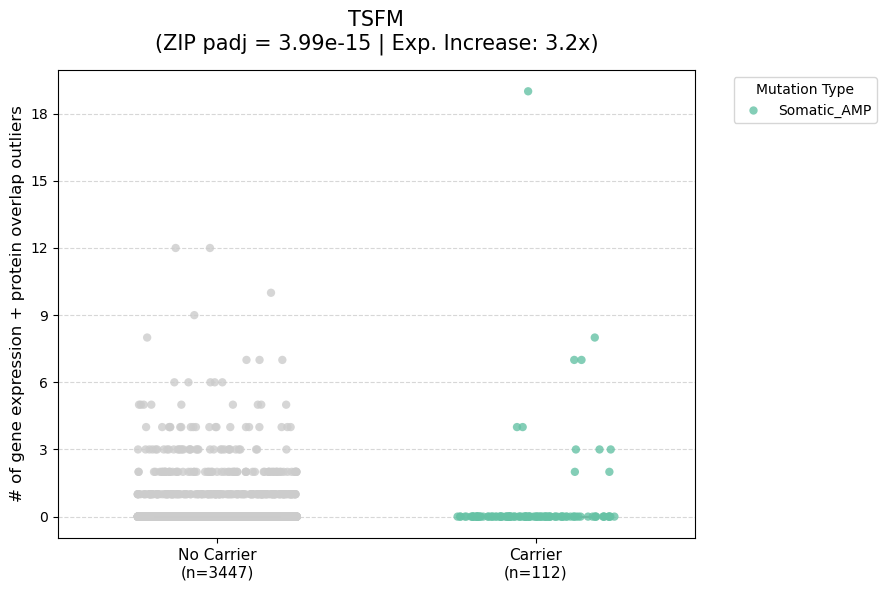

In [23]:
top_5_zip_genes = zip_stats.head(5)['Gene'].tolist()
#plot_zip_results(top_5_zip_genes, res, burden_df, zip_stats)

# can also plot individual genes of interest, eg:
plot_zip_results(['TSFM'], res, burden_df, zip_stats)

Two-part hurdle model

In [29]:
def run_hurdle_model(genes_to_test, res_df, burden_df):
    # 1. Logit: does CNV predict presence of burden (binary)?
    # 2. Truncated Poisson: does CNV predict burden magnitude >0?

    results = []

    for gene in tqdm(genes_to_test, desc="Running Hurdle tests"):
        gene_data = res_df[res_df['geneID_filtered'] == gene]
        variant_summary = gene_data.groupby(SAMPLE_ID).size().reset_index(name='CNV_Count')
        model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left').fillna(0)
        model_data['has_cnv'] = (model_data['CNV_Count'] > 0).astype(int)
        
        if model_data['has_cnv'].sum() < 3 or (model_data['burden'] > 0).sum() < 3:
            continue

        Y = model_data['burden']
        X = sm.add_constant(model_data['has_cnv'])

        try:
            y_binary = (Y > 0).astype(int)
            logit_model = sm.Logit(y_binary, X).fit(disp=False)
            
            pos_data = model_data[model_data['burden'] > 0].copy()
            Y_pos = pos_data['burden']
            X_pos = sm.add_constant(pos_data['has_cnv'])
            
            trunc_model = sm.Poisson(Y_pos, X_pos).fit(disp=False)

            results.append({
                'Gene': gene,
                'logit_p': logit_model.pvalues['has_cnv'],
                'trunc_p': trunc_model.pvalues['has_cnv']
            })
        except:
            continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        _, results_df['padj'], _, _ = multipletests(results_df['logit_p'], method='fdr_bh')
        results_df = results_df.sort_values('logit_p')

    return results_df

In [30]:
carrier_counts = (
    res[res['geneID_filtered'].isin(strict_overlap['geneID_filtered'])]
    .drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
    ['geneID_filtered']
    .value_counts()
)

genes_strict_overlap = carrier_counts[carrier_counts >= 5].index.tolist()

hurdle_stats = run_hurdle_model(genes_strict_overlap, res, burden_df)

Running Hurdle tests:   0%|          | 0/623 [00:00<?, ?it/s]

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

Logistic regression

In [31]:
# logistic test (logistic regression => find whether a variant increases likelihood for an outlier, but not by how much)
def run_logistic_tests(genes_to_test, res_df, burden_df):
    results = []
    res_copy = res_df.copy()

    def summarize_variant(group):
        origins = set(group['origin'])
        types = set(group['Type'])
        if 'somatic' in origins and 'germline' in origins:
            origin_label = "Both"
        else:
            origin_label = list(origins)[0].capitalize()
        type_label = "/".join(sorted(types))
        return f"{origin_label}_{type_label}"

    for gene in tqdm(genes_to_test, desc="Running Logistic tests"):
        gene_data = res_copy[res_copy['geneID_filtered'] == gene]

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        model_data['has_cnv'] = np.where(model_data['CNV_Type'].isna(), 0, 1)
        
        model_data['is_outlier'] = (model_data['burden'] > 0).astype(int)

        n_carriers = model_data['has_cnv'].sum()
        n_outliers = model_data['is_outlier'].sum()

        if n_carriers < 3 or n_outliers < 3:
            continue

        Y = model_data['is_outlier']
        X = sm.add_constant(model_data['has_cnv'])

        try:
            logit_model = sm.Logit(endog=Y, exog=X)
            logit_results = logit_model.fit(disp=False)

            p_val = logit_results.pvalues['has_cnv']
            coef = logit_results.params['has_cnv']

            results.append({
                'Gene': gene,
                'n_carriers': n_carriers,
                'coef': coef,
                'p_val': p_val,
                'converged': logit_results.mle_retvals['converged']
            })

        except Exception as e:
            pass

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df[results_df['converged'] == True].copy()
        results_df = results_df.dropna(subset=['p_val'])
        
        if not results_df.empty:
            _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
            results_df = results_df.sort_values('p_val')

    return results_df

In [32]:
log_stats = run_logistic_tests(genes_strict_overlap, res, burden_df) # A failed approach: zero-inflated negative binomial. Lots of "Hessian Inversion Warnings", likely due to mostly zeroes. 

Running Logistic tests:   0%|          | 0/623 [00:00<?, ?it/s]

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

Plotting the Hurdle test & Logistic Regression results

In [33]:
# same manner of plotting as before
def plot_model_comparison(top_genes_list, res_df, burden_df, logit_stats, hurdle_stats):
    for gene in top_genes_list:
        logit_row = logit_stats[logit_stats['Gene'] == gene]
        hurdle_row = hurdle_stats[hurdle_stats['Gene'] == gene]
        
        if logit_row.empty or hurdle_row.empty:
            print(f"Stats missing for {gene}, skipping plot.")
            continue
            
        logit_padj = logit_row.iloc[0]['padj']
        logit_coef = logit_row.iloc[0]['coef']
        odds_ratio = np.exp(logit_coef) 
        
        trunc_p = hurdle_row.iloc[0]['trunc_p']

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        plot_df = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))


        plt.axhspan(-0.5, 0.5, color='gray', alpha=0.1, zorder=0)

        sns.boxplot(data=plot_df, x='Group', y='burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5, zorder=1)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8, zorder=2)

        title_text = (
            f"{gene}\n"
            f"Logit padj: {logit_padj:.2e} (Odds Ratio: {odds_ratio:.1f}x)\n"
            f"Hurdle Truncated p-val: {trunc_p:.3f}"
        )
        plt.title(title_text, fontsize=14, pad=15)

        plt.ylabel("# of gene expression + protein overlap outliers", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if plt.gca().get_legend():
                plt.gca().get_legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

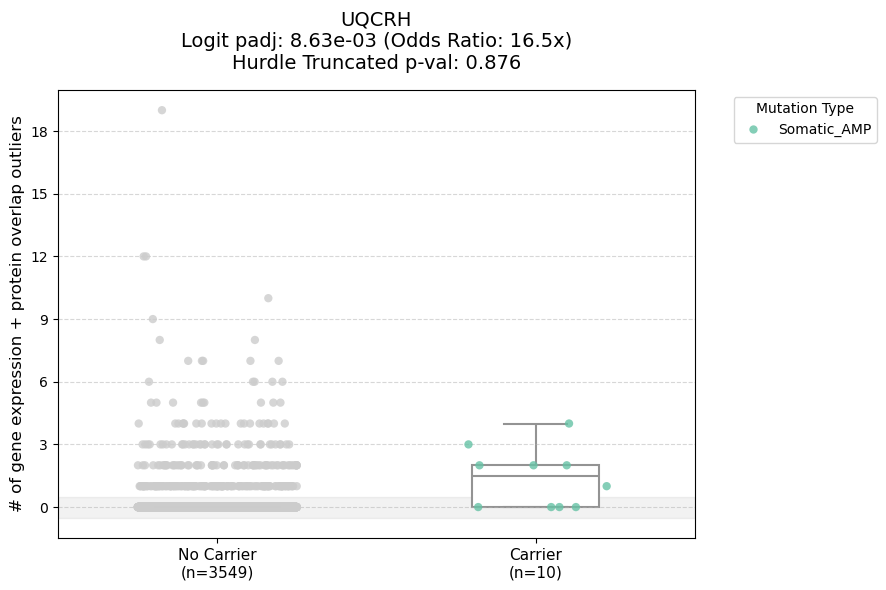

In [34]:
top_genes = log_stats.head(1)['Gene'].tolist()
plot_model_comparison(top_genes, res, burden_df, log_stats, hurdle_stats)


# Explanation of graph:
# - X-Axis: carrier => patient who has a muation on a given gene 
# - Y-Axis: number of outliers in the gene expression + protein overlap (= burden)
# - Logit padj: adjusted p-value of the logistical regression => whether a CNV on that gene causes an outlier, and by how much (Odds Ratio)
# - Hurdle truncated p-val: only for carriers with y>0, does a CNV increase the burden? 

In [35]:
# compare the two models 
def plot_log_hurdle_comp(logit_df, hurdle_df, top_n):
    top_n_genes = logit_df.sort_values('padj').head(top_n)[['Gene', 'padj']].copy()
    
    merged_df = pd.merge(top_n_genes, hurdle_df[['Gene', 'trunc_p']], on='Gene', how='left')
    
    merged_df['Logistic padj'] = -np.log10(merged_df['padj'] + 1e-300)
    merged_df['Truncated p-val'] = -np.log10(merged_df['trunc_p'] + 1e-300)
    
    melted_df = pd.melt(merged_df, id_vars=['Gene'], 
                        value_vars=['Logistic padj', 'Truncated p-val'],
                        var_name='Statistical Test', value_name='-log10(p-value)')
    
    plt.figure(figsize=(10, 6))
    
    
    ax = sns.barplot(data=melted_df, x='Gene', y='-log10(p-value)', 
                     hue='Statistical Test', palette='Set2')
    
    threshold = -np.log10(0.05)
    plt.axhline(threshold, color='black', linestyle='--', alpha=0.7, zorder=0)
    plt.text(top_n, threshold, 'p = 0.05', color='black', fontsize=10)
    
    plt.title(f'Top {top_n} Genes of Logistic Regression vs Hurdle Model', fontsize=15, pad=15)
    plt.ylabel('-log10(p-value)', fontsize=12)
    plt.xlabel('Gene', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

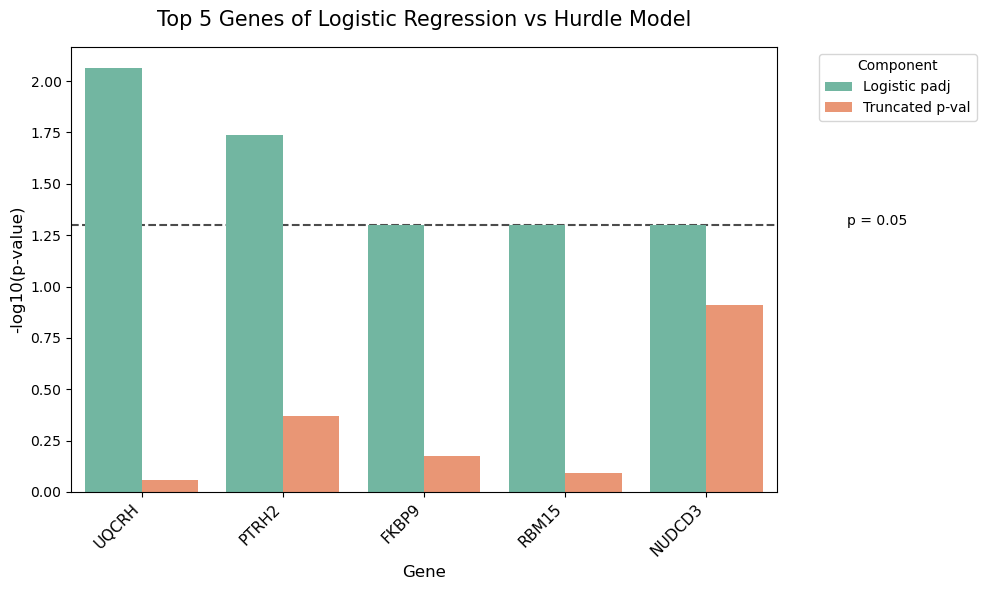

In [36]:
plot_log_hurdle_comp(log_stats, hurdle_stats, top_n=5)

# Models updated for chromosome-awareness

In [37]:
def run_logistic_chrom_aware(genes_to_test, res_df, chrom_counts_matrix):
    valid_res = res_df.dropna(subset=['chrom'])
    valid_genes = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes]

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    results = []

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in tqdm(genes_by_chrom.items(), desc="Running Chrom-Aware Logistic"):
        
        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        
        y_binary = (adj_burden > 0).astype(int)

        for gene in genes:
            gene_data = valid_res[valid_res['geneID_filtered'] == gene]
            carrier_samples = gene_data[SAMPLE_ID].unique()

            model_data = pd.DataFrame(index=all_samples)
            model_data['has_cnv'] = model_data.index.isin(carrier_samples).astype(int)
            model_data['is_outlier'] = y_binary

            n_carriers = model_data['has_cnv'].sum()
            n_outliers = model_data['is_outlier'].sum()

            if n_carriers < 3 or n_outliers < 3:
                continue

            Y = model_data['is_outlier']
            X = sm.add_constant(model_data['has_cnv'])

            try:
                logit_model = sm.Logit(Y, X).fit(disp=False)

                if logit_model.mle_retvals['converged']:
                    results.append({
                        'Gene': gene,
                        'n_carriers': n_carriers,
                        'coef': logit_model.params['has_cnv'],
                        'p_val': logit_model.pvalues['has_cnv'],
                        'converged': True
                    })
            except Exception:
                continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['p_val'])
        _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
        results_df = results_df.sort_values('padj')

    return results_df

In [38]:
log_stats_chrom = run_logistic_chrom_aware(genes_strict_overlap, res, chrom_counts_gene_prot_overlap)

Running Chrom-Aware Logistic: 0it [00:00, ?it/s]

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

In [39]:
def run_hurdle_chrom_aware(genes_to_test, res_df, chrom_counts_matrix):
    valid_res = res_df.dropna(subset=['chrom'])
    valid_genes = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes]

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    results = []

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in tqdm(genes_by_chrom.items(), desc="Running Chrom-Aware Hurdle"):
        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        y_binary = (adj_burden > 0).astype(int)

        for gene in genes:
            gene_data = valid_res[valid_res['geneID_filtered'] == gene]
            carrier_samples = gene_data[SAMPLE_ID].unique()

            model_data = pd.DataFrame(index=all_samples)
            model_data['has_cnv'] = model_data.index.isin(carrier_samples).astype(int)
            model_data['adj_burden'] = adj_burden
            model_data['is_outlier'] = y_binary

            if model_data['has_cnv'].sum() < 3 or model_data['is_outlier'].sum() < 3:
                continue

            try:
                Y_logit = model_data['is_outlier']
                X_logit = sm.add_constant(model_data['has_cnv'])
                logit_model = sm.Logit(Y_logit, X_logit).fit(disp=False)
                
                if not logit_model.mle_retvals['converged']:
                    continue

                pos_data = model_data[model_data['adj_burden'] > 0]
                Y_pos = pos_data['adj_burden']
                X_pos = sm.add_constant(pos_data['has_cnv'])
                
                trunc_model = sm.Poisson(Y_pos, X_pos).fit(disp=False)

                if np.isnan(trunc_model.pvalues['has_cnv']):
                    continue

                results.append({
                    'Gene': gene,
                    'logit_p': logit_model.pvalues['has_cnv'],
                    'trunc_p': trunc_model.pvalues['has_cnv']
                })
            except Exception:
                continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['logit_p'])
        _, results_df['padj'], _, _ = multipletests(results_df['logit_p'], method='fdr_bh')
        results_df = results_df.sort_values('padj')

    return results_df

In [40]:
hurdle_stats_chrom = run_hurdle_chrom_aware(genes_strict_overlap, res, chrom_counts_gene_prot_overlap)

Running Chrom-Aware Hurdle: 0it [00:00, ?it/s]

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

In [41]:
def plot_chrom_aware_model(top_genes_list, res_df, chrom_counts_matrix, logit_stats, hurdle_stats):
    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    for gene in top_genes_list:
        logit_row = logit_stats[logit_stats['Gene'] == gene]
        hurdle_row = hurdle_stats[hurdle_stats['Gene'] == gene]
        
        if logit_row.empty or hurdle_row.empty:
            print(f"Stats missing for {gene}, skipping plot.")
            continue
            
        logit_padj = logit_row.iloc[0]['padj']
        logit_coef = logit_row.iloc[0]['coef']
        odds_ratio = np.exp(logit_coef) 
        trunc_p = hurdle_row.iloc[0]['trunc_p']

        gene_data = res_df[res_df['geneID_filtered'] == gene].dropna(subset=['chrom']).copy()
        if gene_data.empty:
            print(f"No valid chromosome data for {gene}, skipping.")
            continue
            
        chrom = gene_data['chrom'].iloc[0] 

        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        
        adj_burden_df = adj_burden.reset_index()
        adj_burden_df.columns = [SAMPLE_ID, 'adj_burden'] 

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')

        plot_df = pd.merge(adj_burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))

        plt.axhspan(-0.5, 0.5, color='gray', alpha=0.1, zorder=0)

        sns.boxplot(data=plot_df, x='Group', y='adj_burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5, zorder=1)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='adj_burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8, zorder=2)

        title_text = (
            f"{gene} (Chromosome-Aware)\n"
            f"Logit padj: {logit_padj:.2e} (Odds Ratio: {odds_ratio:.1f}x)\n"
            f"Hurdle Truncated p-val: {trunc_p:.3f}"
        )
        plt.title(title_text, fontsize=14, pad=15)

        plt.ylabel(f"Adjusted Outlier Burden\n(Excluding Chromosome {chrom})", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if plt.gca().get_legend():
                plt.gca().get_legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

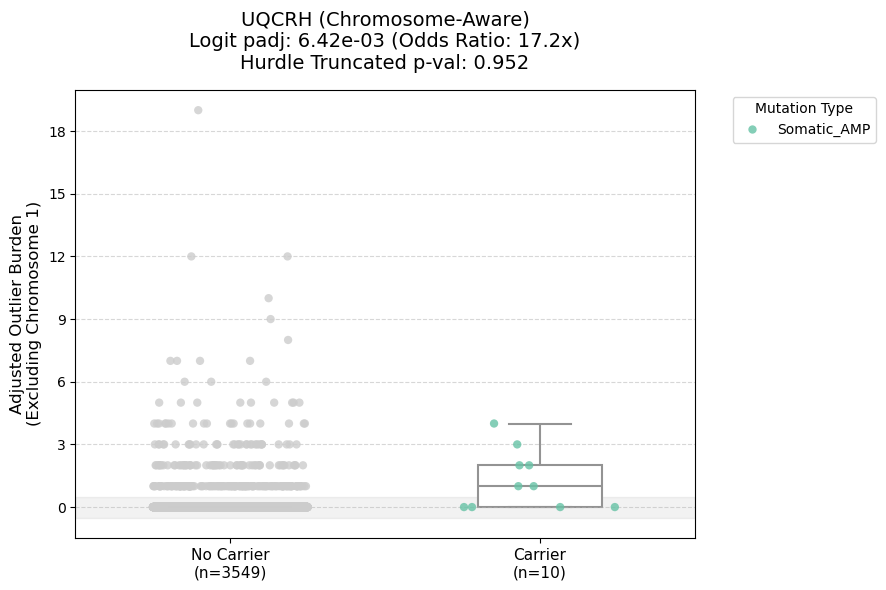

In [42]:
plot_chrom_aware_model(['UQCRH'], res, chrom_counts_gene_prot_overlap, log_stats_chrom, hurdle_stats_chrom)

Visualisation of the genes that were flagged as significant (or very close to p=0.05) before.
Image created using [PhenoGram](https://visualization.ritchielab.org/phenograms/plot)

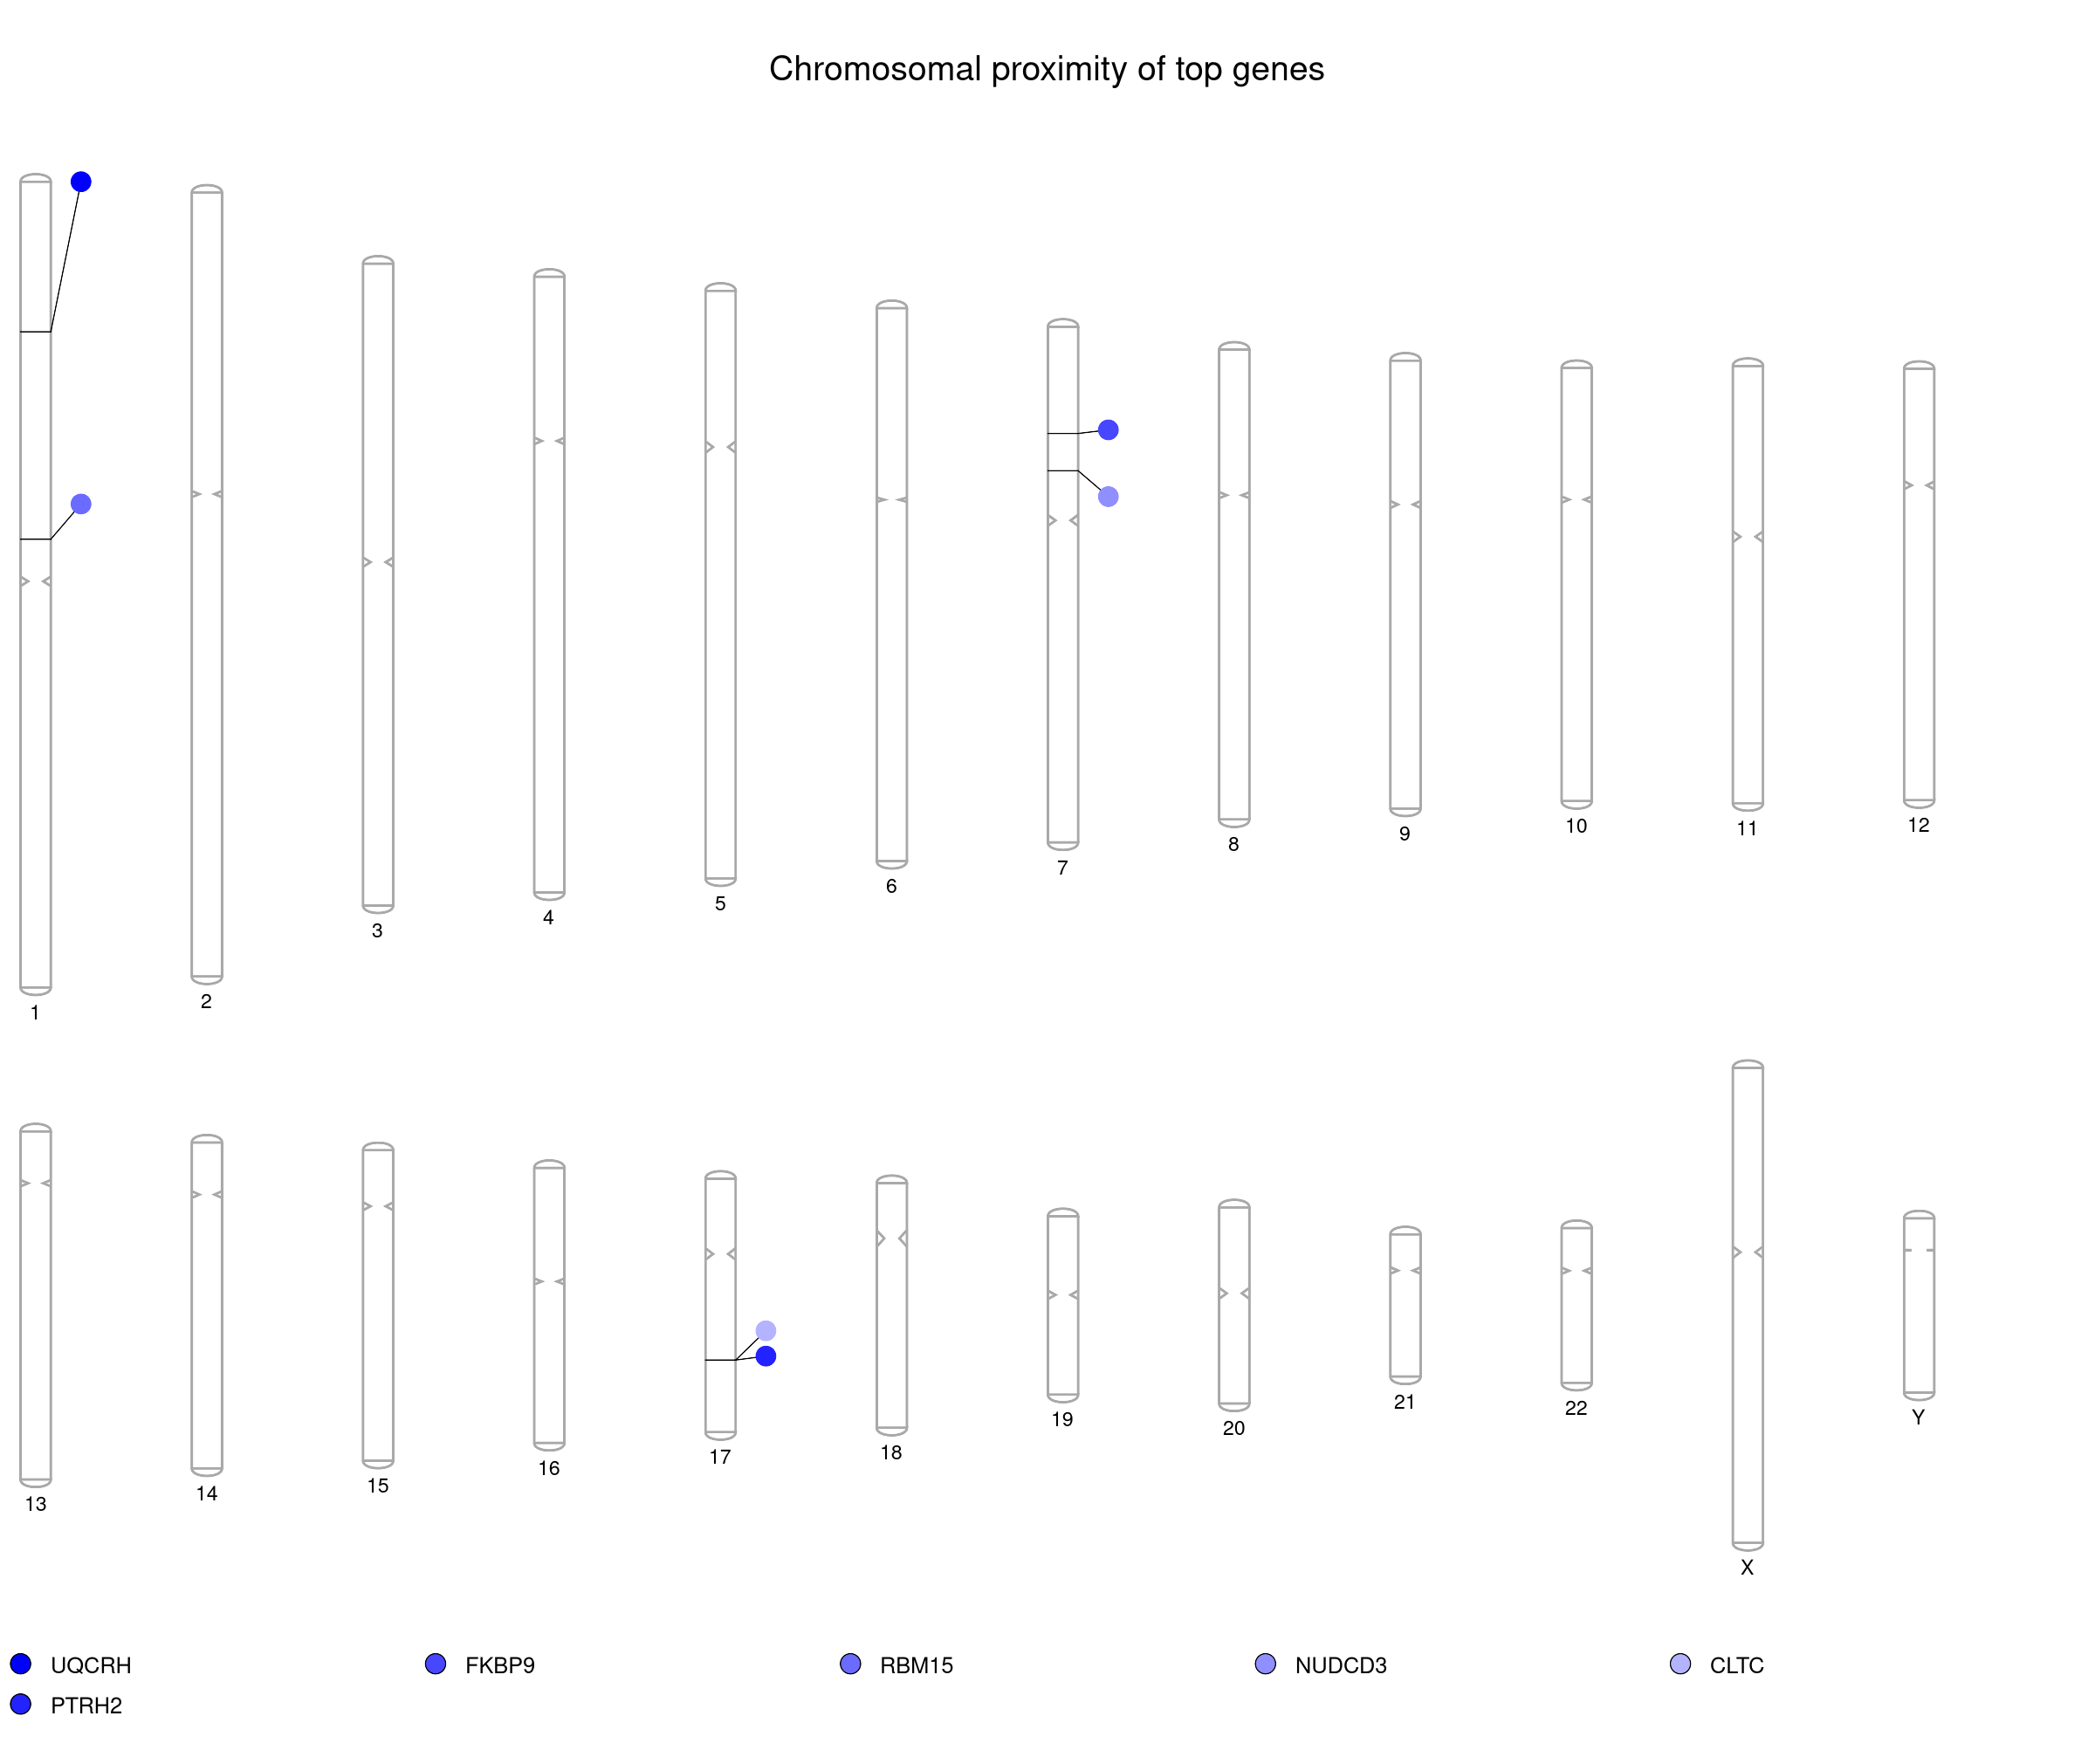

In [46]:
display(Image(filename="pheno_gram.20576.png"))